In [4]:
%matplotlib inline 
# ^^^ THIS IS THE MAGIC LINE TO FIX "NO IMAGES"

import os
import json
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import gc
import joblib
from collections import Counter
from PIL import Image
from torchvision import models, transforms
from skimage.feature import hog

# ==========================================
# 🛑 CONFIGURATION
# ==========================================
DATA_DIR = os.path.join("..", "data")
IMG_DIR = os.path.join(DATA_DIR, "Cropped")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Definitions
MODEL_TYPES = {
    "MobileNet":    {"base": "mobilenet",    "ext": ".pth",    "type": "deep", "csv": "mobilenet_all_results.csv"},
    "ResNet50":     {"base": "resnet50",     "ext": ".pth",    "type": "deep", "csv": "resnet50_all_results.csv"},
    "SqueezeNet":   {"base": "squeezenet",   "ext": ".pth",    "type": "deep", "csv": "squeezenet_all_results.csv"},
    "EfficientNet": {"base": "efficientnet", "ext": ".pth",    "type": "deep", "csv": "efficientnet_all_results.csv"},
    "YOLOv8":       {"base": "yolov8",       "ext": ".pt",     "type": "yolo", "csv": "yolov8_all_results.csv"},
    "HOG_SVM":      {"base": "hog_svm",      "ext": ".joblib", "type": "ml",   "csv": "hog_svm_all_results.csv"}
}
VARIANTS = ["raw", "unified", "customized"]

print(f"✅ Environment Configured. Device: {DEVICE}")

✅ Environment Configured. Device: cuda


In [5]:
def load_single_model(model_name, variant, file_path):
    if not os.path.exists(file_path): 
        # Only warn for HOG to keep output clean
        if model_name == "HOG_SVM": print(f"   ⚠️ File Missing: {os.path.basename(file_path)}")
        return None
    try:
        model = None
        if model_name == "MobileNet":
            model = models.mobilenet_v2(pretrained=False)
            model.classifier[1] = nn.Linear(model.last_channel, len(CATEGORIES))
            model.load_state_dict(torch.load(file_path, map_location=DEVICE))
        elif model_name == "ResNet50":
            model = models.resnet50(pretrained=False)
            model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
            model.load_state_dict(torch.load(file_path, map_location=DEVICE))
        elif model_name == "SqueezeNet":
            model = models.squeezenet1_1(pretrained=False)
            model.classifier[1] = nn.Conv2d(512, len(CATEGORIES), kernel_size=(1,1))
            model.num_classes = len(CATEGORIES)
            model.load_state_dict(torch.load(file_path, map_location=DEVICE))
        elif model_name == "EfficientNet":
            model = models.efficientnet_b0(pretrained=False)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(CATEGORIES))
            model.load_state_dict(torch.load(file_path, map_location=DEVICE))
        elif model_name == "YOLOv8":
            from ultralytics import YOLO
            model = YOLO(file_path)
        elif model_name == "HOG_SVM":
            model = joblib.load(file_path)
        
        if model_name not in ["YOLOv8", "HOG_SVM"] and model:
            model = model.to(DEVICE).eval()
        return model
    except Exception as e:
        print(f"   ❌ Error loading {os.path.basename(file_path)}: {e}")
        return None

def predict_with_model(model, model_name, img_pil):
    try:
        if model_name == "HOG_SVM":
            # RESIZE FIX: Force 128x128 for SVM
            img_resized = img_pil.resize((128, 128))
            img_gray = np.array(img_resized.convert("L"))
            fd = hog(img_gray, orientations=9, pixels_per_cell=(8, 8), 
                     cells_per_block=(2, 2), visualize=False).reshape(1, -1)
            prediction = model.predict(fd)[0]
            if isinstance(prediction, str): return prediction
            else: return CATEGORIES[int(prediction)]
        elif model_name == "YOLOv8":
            results = model.predict(img_pil, verbose=False)
            return results[0].names[results[0].probs.top1]
        else:
            transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
            img_t = transform(img_pil).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(img_t)
                _, preds = torch.max(out, 1)
                return CATEGORIES[preds.item()]
    except: return None

def get_official_accuracy(csv_filename):
    path = os.path.join(DATA_DIR, csv_filename)
    if os.path.exists(path):
        try: return pd.read_csv(path)['Accuracy'].max()
        except: return 0.0
    return 0.0

print("✅ Functions Loaded.")

✅ Functions Loaded.


📂 Scanning folder: ..\data\Cropped...
✅ Found 830 images.
🚀 Starting Grand Ensemble Demo on 8 images...
🧠 Evaluating MobileNet... 

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_11964\3554395761.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future re

✅ Loaded 3 variants.
🧠 Evaluating ResNet50... 

C:\Users\User\AppData\Local\Temp\ipykernel_11964\3554395761.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path, map_location=DEV

✅ Loaded 3 variants.
🧠 Evaluating SqueezeNet... 

C:\Users\User\AppData\Local\Temp\ipykernel_11964\3554395761.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path, map_location=DEV

✅ Loaded 3 variants.
🧠 Evaluating EfficientNet... 

C:\Users\User\AppData\Local\Temp\ipykernel_11964\3554395761.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path, map_location=DEV

✅ Loaded 3 variants.
🧠 Evaluating YOLOv8... ✅ Loaded 3 variants.
🧠 Evaluating HOG_SVM... ✅ Loaded 3 variants.

🎨 Generating Scoreboard...


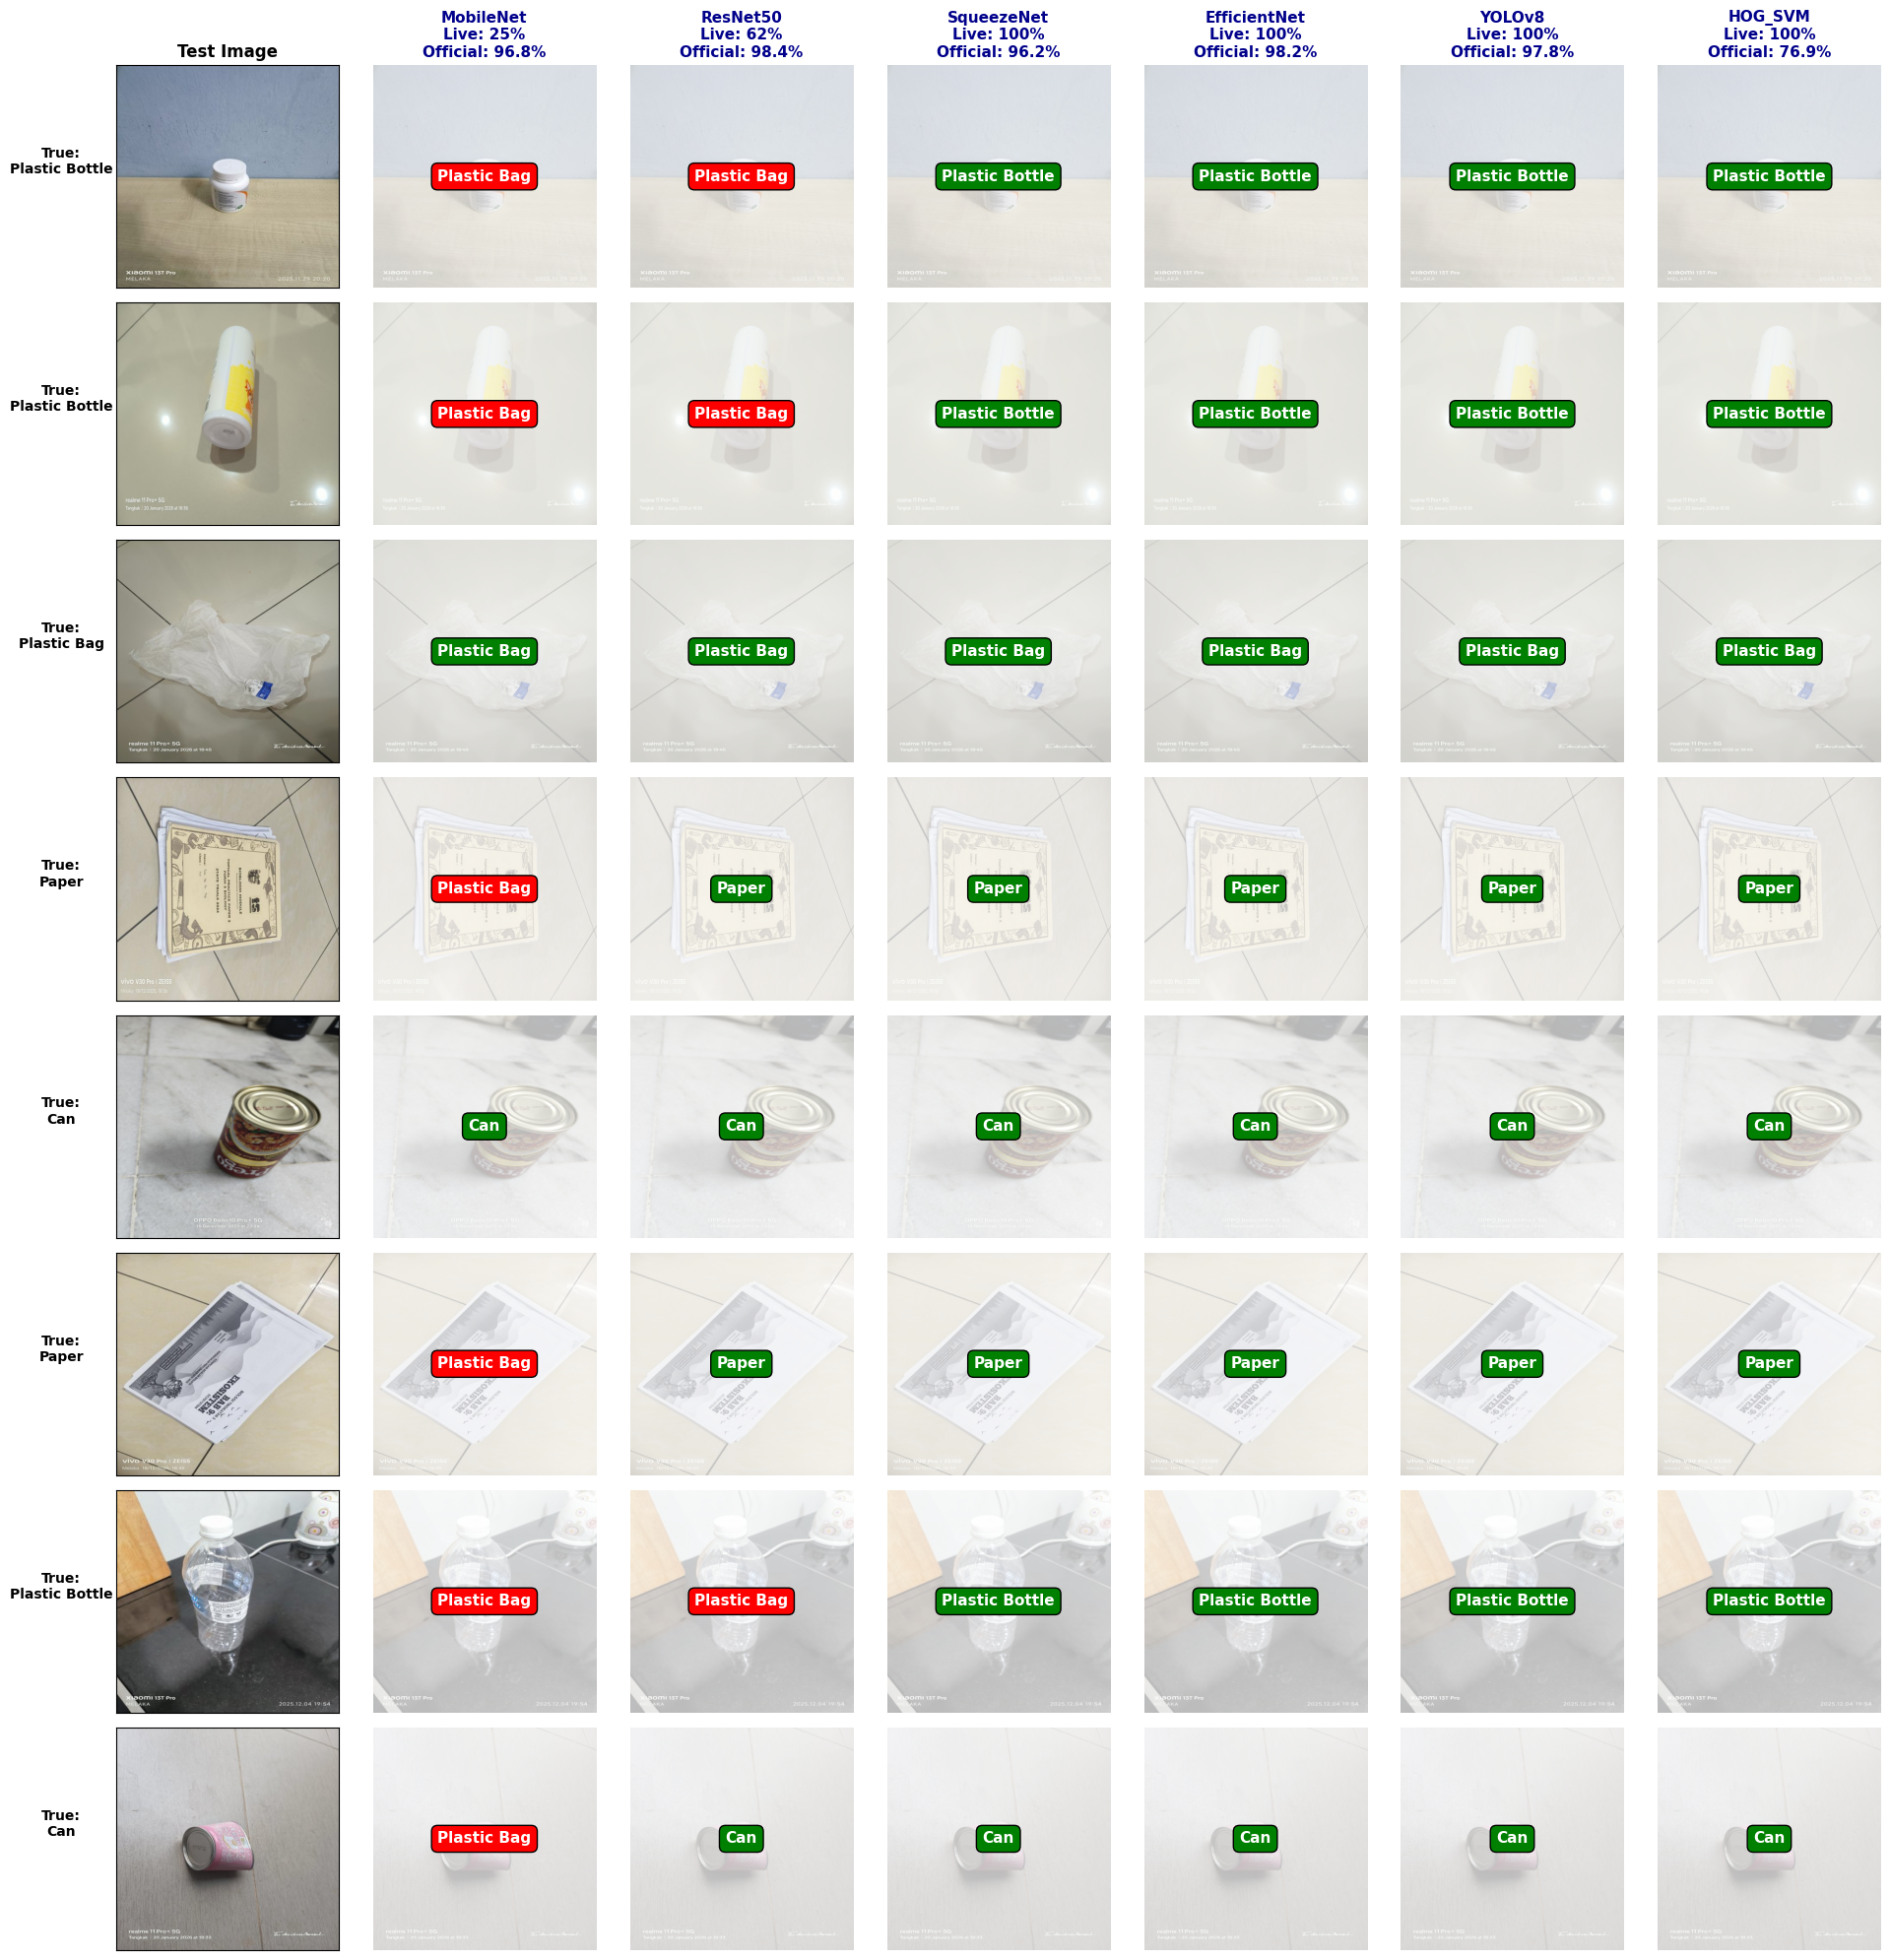

In [9]:
if os.path.exists(IMG_DIR):
    # 1. AUTO-DISCOVER IMAGES (Ignore JSON)
    # This scans the folders live to find whatever files are actually there
    all_image_files = []
    print(f"📂 Scanning folder: {IMG_DIR}...")
    
    for root, dirs, files in os.walk(IMG_DIR):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                # Create relative path (e.g., "Can/image_01.jpg")
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, IMG_DIR)
                all_image_files.append(rel_path)

    if not all_image_files:
        print("❌ No images found! Check your Cropped folder.")
    else:
        print(f"✅ Found {len(all_image_files)} images.")

        # 2. Pick Random Images
        n_samples = min(8, len(all_image_files))
        random_samples = random.sample(all_image_files, n_samples)
        
        demo_results = {i: {} for i in range(len(random_samples))}
        live_scores = {m: 0 for m in MODEL_TYPES.keys()}
        official_scores = {}

        print(f"🚀 Starting Grand Ensemble Demo on {n_samples} images...")

        # 3. Main Model Loop
        for m_name, m_config in MODEL_TYPES.items():
            print(f"🧠 Evaluating {m_name}...", end=" ")
            
            # Get CSV Accuracy (Historical Reference)
            official_scores[m_name] = get_official_accuracy(m_config['csv'])
            
            variants_loaded = []
            for v in VARIANTS:
                fname = f"{m_config['base']}_{v}{m_config['ext']}"
                fpath = os.path.join(DATA_DIR, fname)
                model = load_single_model(m_name, v, fpath)
                if model: variants_loaded.append(model)
            
            if variants_loaded:
                print(f"✅ Loaded {len(variants_loaded)} variants.")
                
                for i, rel_path in enumerate(random_samples):
                    img_path = os.path.join(IMG_DIR, rel_path)
                    try:
                        # Determine True Label from Folder Name
                        clean_path = rel_path.replace("\\", "/") 
                        # Use the immediate parent folder name as the label
                        true_label = clean_path.split("/")[0]
                        
                        # Verify label is valid (Case Insensitive)
                        is_valid_label = False
                        for c in CATEGORIES:
                            if c.lower() == true_label.lower(): 
                                true_label = c # Normalize casing
                                is_valid_label = True
                                break
                        
                        if not is_valid_label:
                            # Fallback: Search path for category name
                            for c in CATEGORIES: 
                                 if c in rel_path: true_label = c; break

                        pil_img = Image.open(img_path).convert("RGB")
                        
                        # Vote
                        votes = []
                        for v_model in variants_loaded:
                            g = predict_with_model(v_model, m_name, pil_img)
                            if g: votes.append(g)
                        
                        if votes:
                            final_guess = Counter(votes).most_common(1)[0][0]
                            is_correct = (final_guess.lower() == true_label.lower())
                            demo_results[i][m_name] = (final_guess, is_correct)
                            if is_correct: live_scores[m_name] += 1
                    except: pass
            else:
                print("❌ No weights found.")
            
            del variants_loaded
            torch.cuda.empty_cache()
            gc.collect()

        # 4. Visualization
        print("\n🎨 Generating Scoreboard...")
        
        if not demo_results:
            print("⚠️ No results to display.")
        else:
            valid_models = [m for m in MODEL_TYPES.keys() if m in demo_results[0]]
            n_cols = len(valid_models) + 1
            n_rows = len(random_samples)
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.5 * n_rows), squeeze=False)

            # HEADERS
            axes[0, 0].set_title("Test Image", fontsize=12, fontweight='bold')
            for j, m_name in enumerate(valid_models):
                live_acc = live_scores[m_name] / n_samples
                off_acc = official_scores.get(m_name, 0.0)
                header_text = f"{m_name}\nLive: {live_acc:.0%}\nOfficial: {off_acc:.1%}"
                axes[0, j+1].set_title(header_text, fontsize=11, fontweight='bold', color='darkblue')

            # ROWS
            for i, rel_path in enumerate(random_samples):
                img_path = os.path.join(IMG_DIR, rel_path)
                clean_path = rel_path.replace("\\", "/") 
                true_label = clean_path.split("/")[0]
                
                # Normalize Label Display
                for c in CATEGORIES: 
                     if c.lower() == true_label.lower(): true_label = c; break

                # Original Image
                try:
                    pil_img = Image.open(img_path).convert("RGB")
                    axes[i, 0].imshow(pil_img)
                    axes[i, 0].set_ylabel(f"True:\n{true_label}", rotation=0, labelpad=40, fontsize=10, fontweight='bold')
                except: pass
                axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

                # Predictions
                for j, m_name in enumerate(valid_models):
                    guess, correct = demo_results[i].get(m_name, ("N/A", False))
                    
                    try: axes[i, j+1].imshow(pil_img, alpha=0.3)
                    except: pass
                    
                    color = 'green' if correct else 'red'
                    text_display = guess
                    if guess == "N/A": 
                        color = 'gray'
                        text_display = "Error"
                        
                    axes[i, j+1].text(0.5, 0.5, text_display, 
                                     transform=axes[i, j+1].transAxes,
                                     ha='center', va='center', fontsize=11, fontweight='bold', color='white', 
                                     bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="black", alpha=1.0))
                    axes[i, j+1].axis('off')

            plt.tight_layout()
            plt.show()
else:
    print(f"❌ Error: Could not find folder at {IMG_DIR}")